In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [3]:
per_df = pd.read_csv('performance.csv')

In [4]:

def calculate_sql_complexity_detailed(sql_query):
    """
    More detailed complexity calculation
    """
    if pd.isna(sql_query) or sql_query == '':
        return 0
    
    sql_upper = sql_query.upper()
    features = {
        'ctes': len(re.findall(r'\bWITH\s+\w+\s+AS', sql_upper)),
        'joins': len(re.findall(r'\b(INNER|LEFT|RIGHT|FULL|OUTER)\s+JOIN\b', sql_upper)),
        'unions': len(re.findall(r'\bUNION\s+(ALL\s+)?SELECT\b', sql_upper)),
        'group_by': 1 if re.search(r'\bGROUP\s+BY\b', sql_upper) else 0,
        'window_functions': 1 if re.search(r'\bOVER\s*\(', sql_upper) else 0,
        'case_statements': len(re.findall(r'\bCASE\s+WHEN\b', sql_upper)),
        'subqueries': len(re.findall(r'\(\s*SELECT\s+', sql_upper)),
        'length': len(sql_query)
    }
    
    # Scoring logic
    score = 0
    
    # CTEs
    if features['ctes'] >= 3:
        score += 2
    elif features['ctes'] >= 1:
        score += 1
    
    # JOINs
    if features['joins'] >= 4:
        score += 2
    elif features['joins'] >= 2:
        score += 1
    
    # Other features
    if features['unions'] > 0:
        score += 1
    if features['case_statements'] >= 3:
        score += 1
    if features['subqueries'] >= 2:
        score += 1
    if features['length'] > 2000:
        score += 1
    
    # Normalize
    if score >= 4:
        return 2  # High
    elif score >= 2:
        return 1  # Medium
    else:
        return 0  # Low # Low



In [5]:
# Apply to your dataframe
per_df['Complexity'] = per_df['SQL'].apply(calculate_sql_complexity_detailed)

# Check distribution
print("Complexity Distribution:")
print(per_df['Complexity'].value_counts().sort_index())

Complexity Distribution:
Complexity
0     61
1    205
2     34
Name: count, dtype: int64


In [6]:
per_df.to_csv("performance_withcomplexity.csv", index=False)

In [10]:
per_df = pd.read_csv("performance_withcomplexity.csv")

In [11]:
# Make sure time_secs is numeric (handle any string values)
per_df['time_secs'] = pd.to_numeric(per_df['time_secs'], errors='coerce')

In [21]:
# Get comprehensive statistics for all queries (before complexity grouping)
per_df['time_secs'].describe(percentiles=[0.25, 0.50, 0.75, 0.95])
# Get statistics
full_data_stats = per_df['time_secs'].describe(percentiles=[0.25, 0.50, 0.75, 0.95])

# Create DataFrame with your exact format
stats_df = pd.DataFrame({
    'count': [full_data_stats['count']],
    'mean': [full_data_stats['mean']],
    'std': [full_data_stats['std']],
    'min': [full_data_stats['min']],
    '25%': [full_data_stats['25%']],
    '50%': [full_data_stats['50%']],
    '75%': [full_data_stats['75%']],
    '95%': [full_data_stats['95%']],
    'max': [full_data_stats['max']]
})

# Display
print("Full Dataset Statistics - Query Execution Time")
stats_df

Full Dataset Statistics - Query Execution Time


,count,mean,std,min,25%,50%,75%,95%,max
0,300.0,11.686882,28.740937,0.08233,0.229067,1.81941,10.81554,51.609726,180.0122


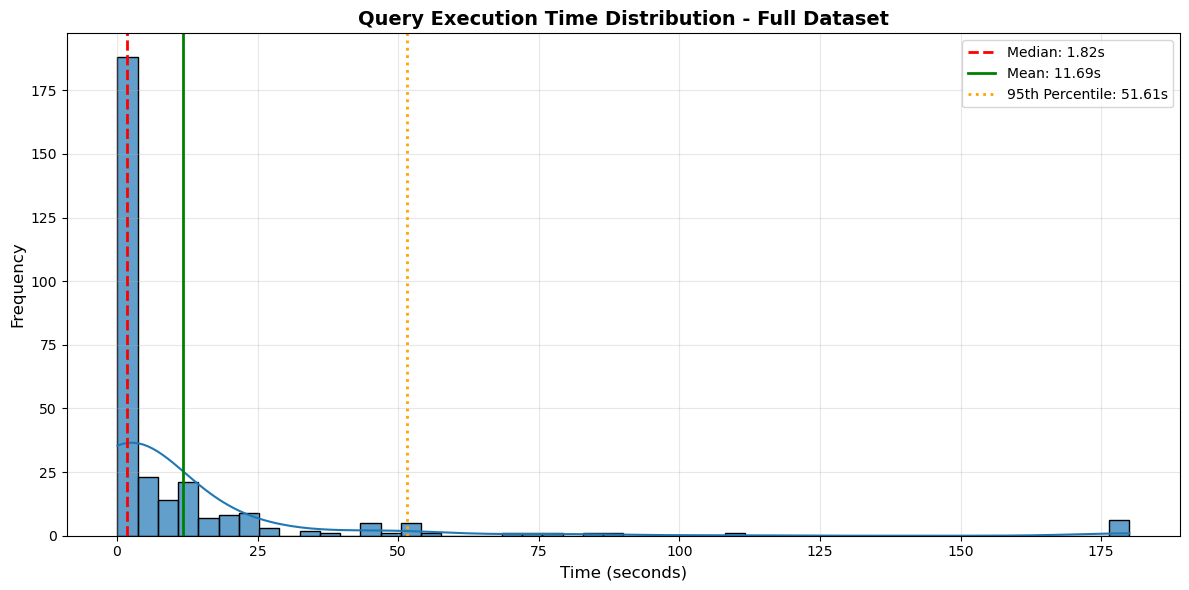

In [15]:
# Create histogram for full dataset
plt.figure(figsize=(12, 6))

# Get the data (drop NaN values)
full_data = per_df['time_secs'].dropna()

# Create histogram with KDE
sns.histplot(full_data, bins=50, kde=True, edgecolor='black', alpha=0.7)

# Add median line (red, dashed)
median_val = full_data.median()
plt.axvline(median_val, color='red', linestyle='--', linewidth=2,
            label=f'Median: {median_val:.2f}s')

# Add mean line (green, solid)
mean_val = full_data.mean()
plt.axvline(mean_val, color='green', linestyle='-', linewidth=2,
            label=f'Mean: {mean_val:.2f}s')

# Add 95th percentile line (orange, dotted) - shows outlier threshold
p95_val = full_data.quantile(0.95)
plt.axvline(p95_val, color='orange', linestyle=':', linewidth=2,
            label=f'95th Percentile: {p95_val:.2f}s')

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Query Execution Time Distribution - Full Dataset', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

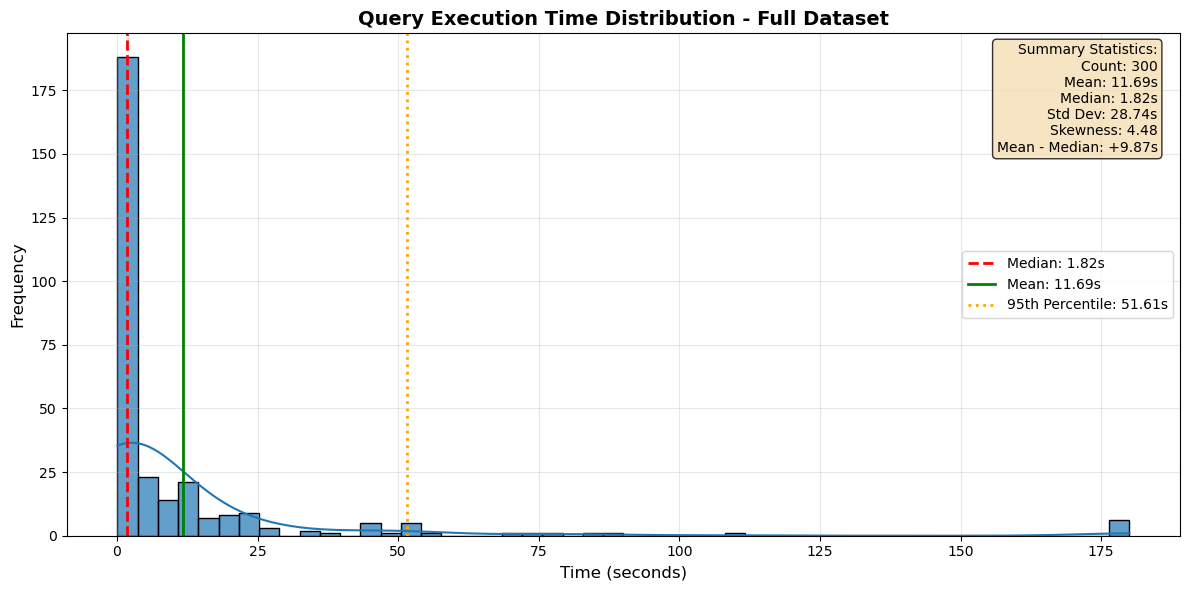

In [16]:
plt.figure(figsize=(12, 6))

full_data = per_df['time_secs'].dropna()

sns.histplot(full_data, bins=50, kde=True, edgecolor='black', alpha=0.7)

# Calculate statistics
median_val = full_data.median()
mean_val = full_data.mean()
p95_val = full_data.quantile(0.95)
skewness = full_data.skew()

# Add lines
plt.axvline(median_val, color='red', linestyle='--', linewidth=2,
            label=f'Median: {median_val:.2f}s')
plt.axvline(mean_val, color='green', linestyle='-', linewidth=2,
            label=f'Mean: {mean_val:.2f}s')
plt.axvline(p95_val, color='orange', linestyle=':', linewidth=2,
            label=f'95th Percentile: {p95_val:.2f}s')

# Add text box with summary statistics
stats_text = f'''Summary Statistics:
Count: {len(full_data)}
Mean: {mean_val:.2f}s
Median: {median_val:.2f}s
Std Dev: {full_data.std():.2f}s
Skewness: {skewness:.2f}
Mean - Median: {mean_val - median_val:+.2f}s'''

plt.text(0.98, 0.98, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=10)

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Query Execution Time Distribution - Full Dataset', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# This gives you 25th, 50th, 75th percentiles automatically
per_df.groupby('Complexity')['time_secs'].describe(percentiles=[0.25, 0.50, 0.75, 0.95])

,count,mean,std,min,25%,50%,75%,95%,max
Complexity,,,,,,,,,
0,61.0,4.873623,23.352376,0.08233,0.183580,0.22984,0.959410,16.810310,180.0122
1,205.0,13.241855,27.240854,0.09925,0.381010,2.74897,11.988490,53.201270,180.0112
2,34.0,14.535093,42.384300,0.14764,0.963533,1.63736,7.722795,78.696694,180.0094


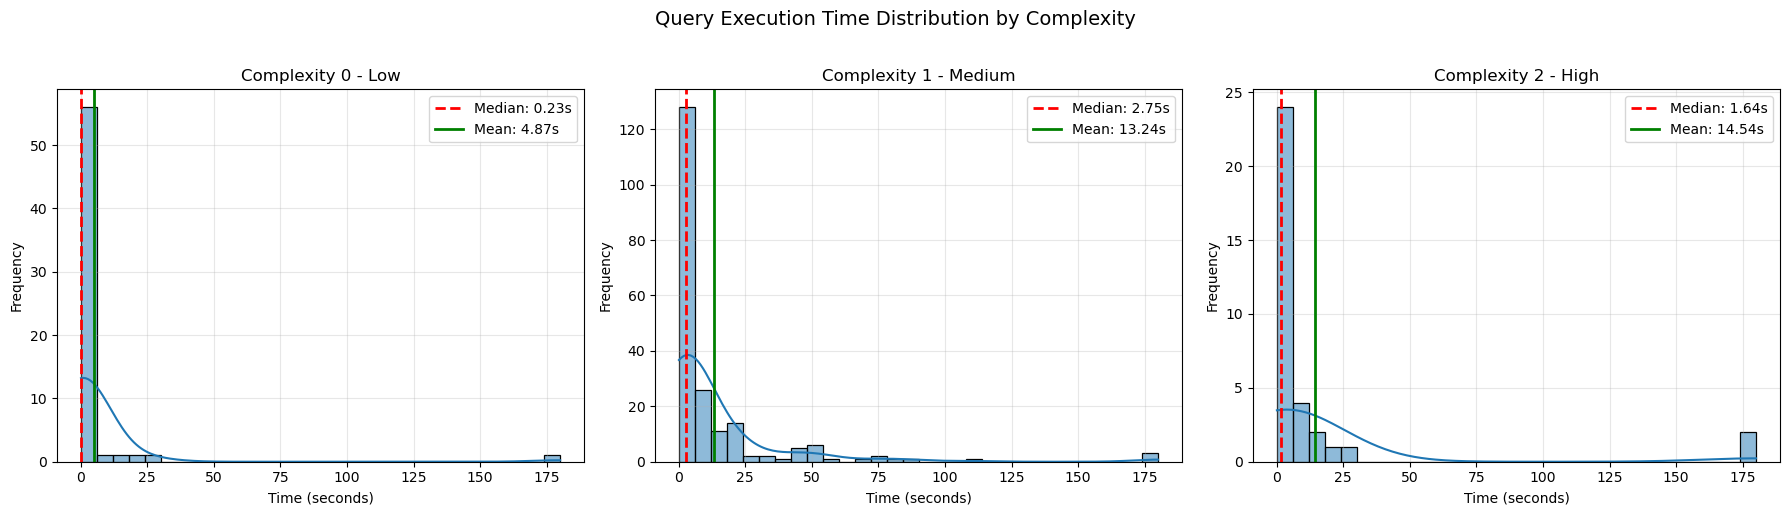

In [9]:
# Create histogram with density curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
complexity_labels = {0: 'Low', 1: 'Medium', 2: 'High'}

for idx, complexity in enumerate(complexity_labels):
    data = per_df[per_df['Complexity'] == complexity]['time_secs'].dropna()
    
    # Create histogram with KDE
    sns.histplot(data, bins=30, kde=True, ax=axes[idx], edgecolor='black')
    
    # Add median line (red, dashed)
    median_val = data.median()
    axes[idx].axvline(median_val, color='red', linestyle='--', linewidth=2,
                      label=f'Median: {median_val:.2f}s')
    
    # Add mean line (green, solid)
    mean_val = data.mean()
    axes[idx].axvline(mean_val, color='green', linestyle='-', linewidth=2,
                      label=f'Mean: {mean_val:.2f}s')
    
    axes[idx].set_title(f'Complexity {complexity} - {complexity_labels[complexity]}')
    axes[idx].set_xlabel('Time (seconds)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Query Execution Time Distribution by Complexity', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()